In [329]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from typing import List

import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [330]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Quest 0.0 - Preprocessing

In [331]:
print(f"Shape:{df.shape}")

Shape:(891, 12)


In [332]:
# Target e Preditores

X = df.drop("Survived", axis=1)
y = df.pop("Survived")

In [333]:
# Removendo algumas variáveis inúteis para análise
X = X.drop(["PassengerId", "Ticket"], axis=1)

In [334]:
X

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,NaN,S
887,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,B42,S
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,NaN,S
889,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C148,C


In [335]:
print(f"Contagem de NaN (X):\n{X.isna().sum()}\n")
print(f"Contagem de NaN (y):\n{y.isna().sum()}")

Contagem de NaN (X):
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Contagem de NaN (y):
0


In [336]:
# Percentual
print(f"Contagem de NaN, em %, (X):\n{X.isna().sum() / len(X)}\n")

Contagem de NaN, em %, (X):
Pclass      0.000000
Name        0.000000
Sex         0.000000
Age         0.198653
SibSp       0.000000
Parch       0.000000
Fare        0.000000
Cabin       0.771044
Embarked    0.002245
dtype: float64



In [337]:
# Entender a relação entre Pclass e a Cabin

# Identificar os valores em que Cabin = NaN
df_w_nan = X[X["Cabin"].isna()]
df_w_nan.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S
5,3,"Moran, Mr. James",male,NaN,0,0,8.4583,NaN,Q
7,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,NaN,S


In [338]:
df_w_nan = X[X["Pclass"]==1]
df_w_nan.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
6,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,E46,S
11,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,26.5500,C103,S
23,1,"Sloper, Mr. William Thompson",male,28.0,0,0,35.5000,A6,S


In [339]:
df_w_nan = X[X["Pclass"]==3]
df_w_nan.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S
5,3,"Moran, Mr. James",male,NaN,0,0,8.4583,NaN,Q
7,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,NaN,S


In [340]:
# Entender as informações para o passageiro que apresenta maior Fare (perigo)

X[X["Fare"] == X["Fare"].max()].head()

# Que conclusões podem ser obtidas a partir disso?
# Passageiros da classe 1 (mais baixa) tende a possuir um perigo maior, além disso, a maioria os homens.

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
258,1,"Ward, Miss. Anna",female,35.0,0,0,512.3292,NaN,C
679,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,512.3292,B51 B53 B55,C
737,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,512.3292,B101,C


### Quest 0.1 - EDA and Feature Engineering

In [341]:
print("Estatística descritiva básica:")
print("X:")
print(X.describe())
print("\n")
print("y:")
print(y.describe())

Estatística descritiva básica:
X:
           Pclass         Age       SibSp       Parch        Fare
count  891.000000  714.000000  891.000000  891.000000  891.000000
mean     2.308642   29.699118    0.523008    0.381594   32.204208
std      0.836071   14.526497    1.102743    0.806057   49.693429
min      1.000000    0.420000    0.000000    0.000000    0.000000
25%      2.000000   20.125000    0.000000    0.000000    7.910400
50%      3.000000   28.000000    0.000000    0.000000   14.454200
75%      3.000000   38.000000    1.000000    0.000000   31.000000
max      3.000000   80.000000    8.000000    6.000000  512.329200


y:
count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64


In [342]:
print("Entender os tipos:")
print(X.dtypes)

Entender os tipos:
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object


In [343]:
# Port of Embarkation:C = Cherbourg, Q = Queenstown, S = Southampton

embarked_map = {
    "C": "Cherbourg",
    "Q": "Queenstown", 
    "S": "Southampton"
}

"""
Usando pandas (user friendly):
X["Embarked"] = X["Embarked"].map(embarked_map)
"""

for element in range(len(X)):
    value = X.loc[element, "Embarked"]
    if value in embarked_map:
        X.loc[element, "Embarked"] = embarked_map[value]

X["Embarked"].value_counts()

Embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

             Pclass  Name  Cabin
Embarked                        
Cherbourg       168   168     69
Queenstown       77    77      4
Southampton     644   644    129


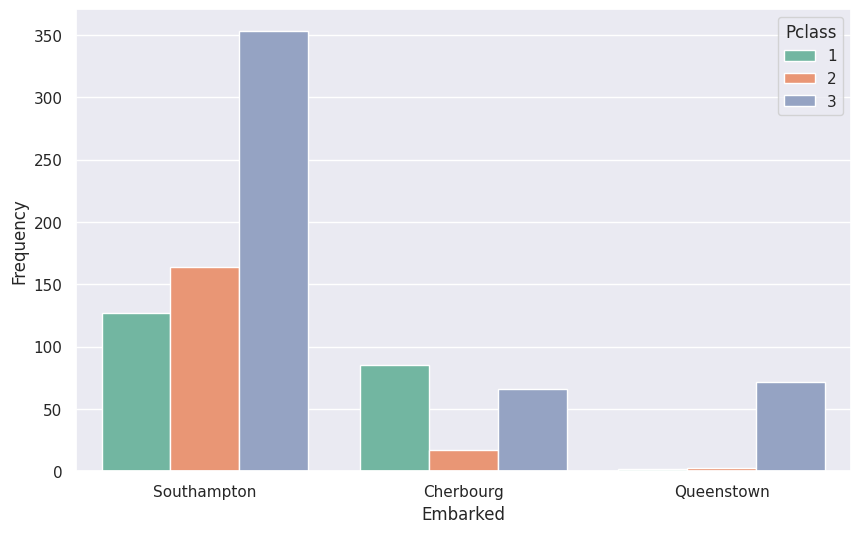

In [344]:
# Procurar entender a relação entre o Embarque com a Classe do passageiro
# Criar um gráfico para cada embarque (y), com a classe do passageiro (x)

agrupamento_embarked = X.groupby(["Embarked"]).count()
print(agrupamento_embarked.drop(["Sex", "Age", "SibSp", "Parch", "Fare"], axis=1))

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
sns.countplot(x="Embarked", data=X, hue="Pclass", palette="Set2")
plt.ylabel("Frequency")
plt.savefig(f"results/embarked_pclass.png")
plt.show()

Podemos concluir que Queenstown é uma cidade de ricos, uma vez que que somente pessoas de class média (1) e alta (2) embarcaram lá, conforme o gráfico;

A cidade Cherbourg é a cidade mais com menor poder monetário, uma vez que a maioria das pessoas que embarcaram lá era classe baixa (0);

A cidade Southampton ainda em sua maioria é classe alta.

In [345]:
X["Cabin"].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [346]:
# Seguinte análise
# Número de irmãos/cônjuges a bordo (0 -> pessoas sozinhas, 1 -> cônjuges/irmão, maior ou igual a 2 é referente a irmãos)
X["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [347]:
# No. of parents / children aboard the Titanic
X["Parch"].head()

0    0
1    0
2    0
3    0
4    0
Name: Parch, dtype: int64

In [348]:
# We can create a new feature Family, see:

X["Family_size"] = X["SibSp"] + X["Parch"] + 1
# Family_size = 1, solo; Family_size = 2, conjuguê/irmãos(as)/amigos(as); Family_size = 3, pai, mãe, filho(a)/irmãos(as)/amigos(as);
X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_size
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,Southampton,2
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,Cherbourg,2
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,Southampton,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,Southampton,2
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,Southampton,1


In [349]:
def family_size(number):
    if number==1:
        return "Alone"
    elif number>1 and number <5:
        return "Small"
    else:
        return "Large"

In [350]:
X['Family_size']=X['Family_size'].apply(family_size)
X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_size
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,Southampton,Small
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,Cherbourg,Small
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,Southampton,Alone
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,Southampton,Small
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,Southampton,Alone


In [351]:
X = X.drop(["SibSp", "Parch"], axis=1)

In [352]:
df_Age_mean=df.groupby(['Sex', 'Pclass']).median(numeric_only=True)['Age']
df_Age_mean

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [353]:
X['Age']=X.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
X['Age'] = X['Age'].astype('int64')

In [354]:
"""
De acordo com IBGE e Estatuto da Criança e do Adolescente as divisões, são mais ou menos assim:
| Faixa etária    | Classificação | Base legal / institucional                 |
| --------------- | ------------- | ------------------------------------------ |
| idade < 12      | Criança       | ECA                                        |
| 12 ≤ idade < 18 | Adolescente   | ECA                                        |
| 18 ≤ idade ≤ 29 | Jovem         | Estatuto da Juventude (Lei nº 12.852/2013) |
| 30 ≤ idade ≤ 59 | Adulto        | IBGE / MS                                  |
| idade ≥ 60      | Idoso         | Estatuto do Idoso (Lei nº 10.741/2003)     |
"""

bins = [-np.inf, 12, 18, 30, 60, np.inf]

#Criaremos essa classificação então
labels = ['child', 'adolescent', 'youth', 'adult', 'elderly']
X['Age_classification'] = pd.cut(
    X['Age'],
    bins=bins,
    labels=labels,
    right=False  # intervals are left-closed, right-open
)

X.head()

,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Family_size,Age_classification
0,3,"Braund, Mr. Owen Harris",male,22,7.2500,NaN,Southampton,Small,youth
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,71.2833,C85,Cherbourg,Small,adult
2,3,"Heikkinen, Miss. Laina",female,26,7.9250,NaN,Southampton,Alone,youth
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,53.1000,C123,Southampton,Small,adult
4,3,"Allen, Mr. William Henry",male,35,8.0500,NaN,Southampton,Alone,adult


In [355]:
X['Title']=X['Name'].str.split(", ",expand=True)[1].str.split(".",expand=True)[0]
X['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [356]:
X['Title'] = X['Title'].replace(['Lady', 'the Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
X['Title'] = X['Title'].replace('Mlle', 'Miss')
X['Title'] = X['Title'].replace('Ms', 'Miss')
X['Title'] = X['Title'].replace('Mme', 'Mrs')

In [357]:
X['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [358]:
X = X.drop(["Name"], axis=1)

In [359]:
X.dtypes

Pclass                   int64
Sex                     object
Age                      int64
Fare                   float64
Cabin                   object
Embarked                object
Family_size             object
Age_classification    category
Title                   object
dtype: object

In [360]:
# Válido remover o Cabin

X = X.drop("Cabin", axis=1)

In [361]:
X.dtypes

Pclass                   int64
Sex                     object
Age                      int64
Fare                   float64
Embarked                object
Family_size             object
Age_classification    category
Title                   object
dtype: object

In [362]:
survive_map = {
    1: "survived",
    0: "no-survived"
}

y_mapped = []

for index in y:
    if index == 0:
        y_mapped.append("survived")
    else:
        y_mapped.append("no-survived")

y_df = {}
y_df["target"]=y_mapped

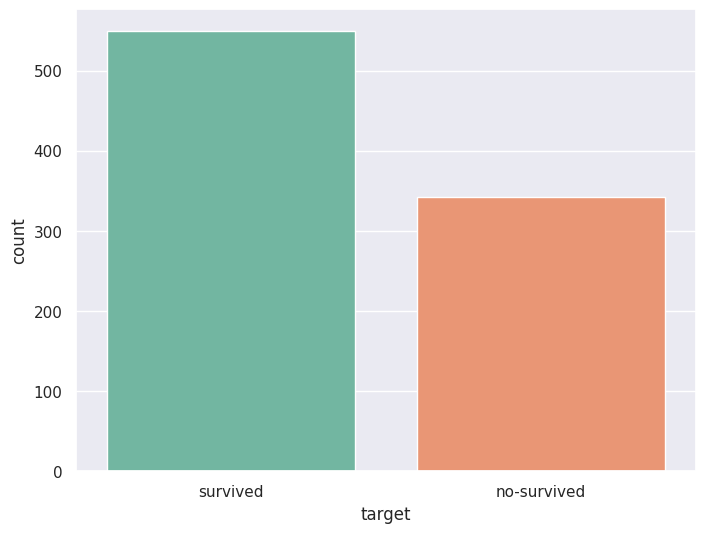

In [363]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))
sns.countplot(x="target", data=y_df, palette="Set2")

plt.savefig(f"results/relation_dead_alive.png")
plt.show()

Count NaN/Null/Ninf/Inf values

In [364]:
print(f"Count NaN values of X:\n{X.isna().sum()/len(X)}")

Count NaN values of X:
Pclass                0.000000
Sex                   0.000000
Age                   0.000000
Fare                  0.000000
Embarked              0.002245
Family_size           0.000000
Age_classification    0.000000
Title                 0.000000
dtype: float64


In [365]:
# Probs of NaN values is from Southampton is high since that big number of people is from Southampton
X['Embarked'].fillna('Southampton',inplace=True)

In [366]:
print(f"Count NaN values of X:\n{X.isna().sum()/len(X)}")

Count NaN values of X:
Pclass                0.0
Sex                   0.0
Age                   0.0
Fare                  0.0
Embarked              0.0
Family_size           0.0
Age_classification    0.0
Title                 0.0
dtype: float64


In [367]:
print(f"Count NaN values of y:\n{y.isna().sum()/len(y)}")

Count NaN values of y:
0.0


In [368]:
col=['Embarked','Pclass','Sex', 'Title','Family_size']
# only for test
X["Survived"] = y
for i in col:
    print('Survival Correlation by:', i)
    df2=X.groupby(i)['Survived'].mean().reset_index()
    print(df2)
    print('-'*10, '\n')

Survival Correlation by: Embarked
      Embarked  Survived
0    Cherbourg  0.553571
1   Queenstown  0.389610
2  Southampton  0.339009
---------- 

Survival Correlation by: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Survival Correlation by: Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
---------- 

Survival Correlation by: Title
    Title  Survived
0  Master  0.575000
1    Miss  0.702703
2      Mr  0.156673
3     Mrs  0.793651
4    Rare  0.347826
---------- 

Survival Correlation by: Family_size
  Family_size  Survived
0       Alone  0.303538
1       Large  0.161290
2       Small  0.578767
---------- 



In [369]:
import plotly.graph_objects as go


fig = go.Figure()

fig.add_trace(go.Histogram(x=X[X['Survived']==0]['Age'], name='Not Survived', opacity=0.5))
fig.add_trace(go.Histogram(x=X[X['Survived']==1]['Age'], name='Survived', opacity=0.5))

fig.update_layout(
    #title='Age Distribution by Survival',
    xaxis_title='Age',
    yaxis_title='Density',
    barmode='overlay',  
    bargap=0.1, 
)

fig.write_image("results/age_distribution_by_survival.png", scale=3)
fig.show()

In [370]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=X[X['Survived']==0]['Age_classification'], name='Not Survived', opacity=0.5))
fig.add_trace(go.Histogram(x=X[X['Survived']==1]['Age_classification'], name='Survived', opacity=0.5))

fig.update_layout(
    #title='Age Distribution by Survival',
    xaxis_title='Age',
    yaxis_title='Density',
    barmode='overlay',  
    bargap=0.1, 
)

fig.write_image("results/classification_age_distribution_by_survival.png", scale=3)
fig.show()

In [371]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=X[X['Survived']==0]['Title'], name='Not Survived', opacity=0.5))
fig.add_trace(go.Histogram(x=X[X['Survived']==1]['Title'], name='Survived', opacity=0.5))

fig.update_layout(
    #title='Age Distribution by Survival',
    xaxis_title='Age',
    yaxis_title='Density',
    barmode='overlay',  
    bargap=0.1, 
)

fig.write_image("results/title_by_survival.png", scale=3)
fig.show()

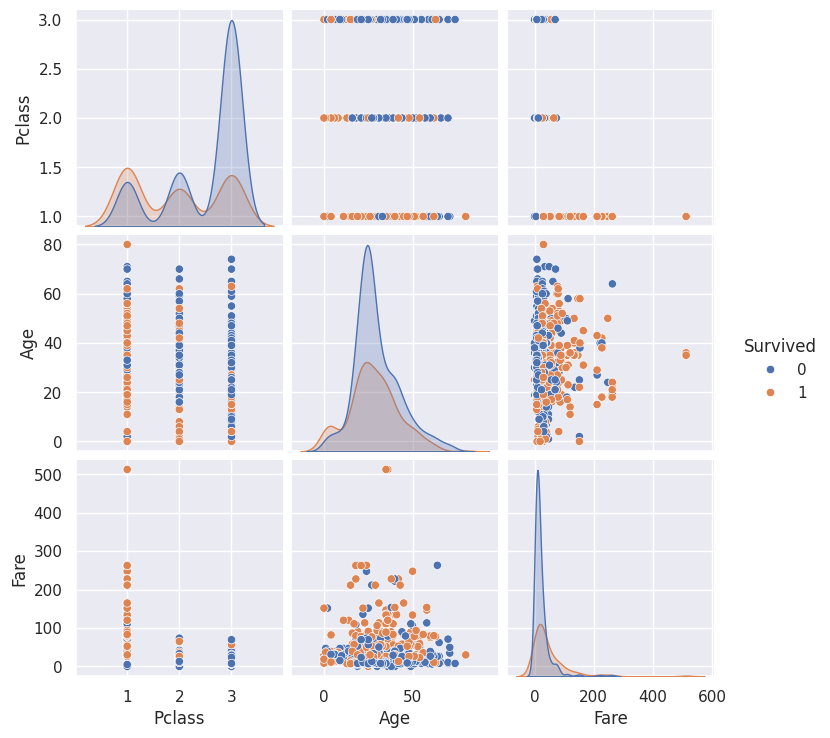

In [372]:
sns.pairplot(X, hue='Survived')
plt.savefig(f"results/bivariate_analise.png")

Análise Condicionada a Classe

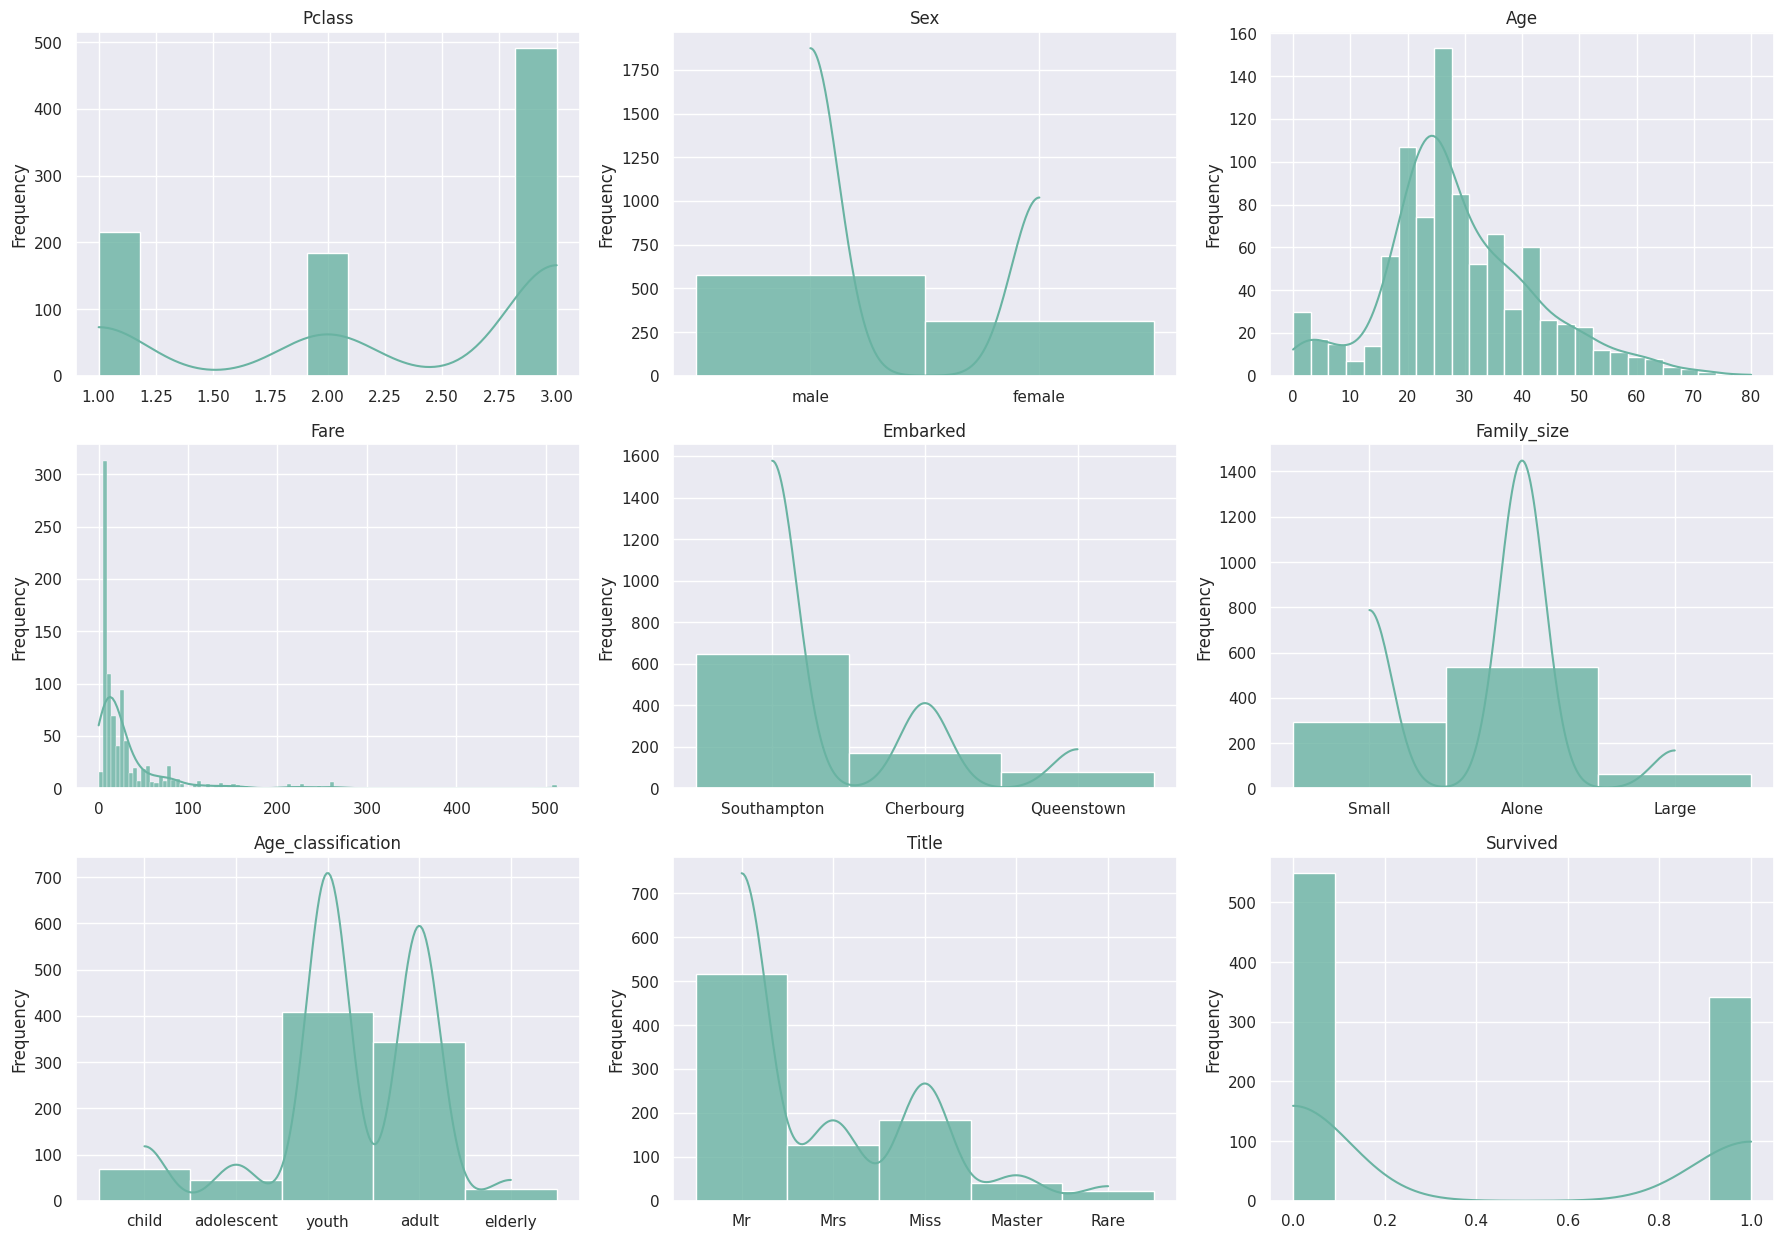

In [373]:
all_columns = X.columns.tolist()
total_plots = len(all_columns)
num_cols = 3
num_rows = math.ceil(total_plots / num_cols) # Estima o número de linhas 

# Cria a figura e a grade de subplots vazia
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4.5))
axes = axes.flatten()

plot_index = 0
alpha_value = 0.8

for col in all_columns:
    ax = axes[plot_index]
    sns.histplot(data=X, 
                    x=col, 
                    ax=ax, 
                    color='#69b3a2', 
                    kde=True,
                    alpha=alpha_value)
    ax.set_title(col)
    ax.set_ylabel("Frequency")
    ax.set_xlabel('')
    plot_index += 1

for i in range(plot_index, len(axes)):
    axes[i].set_visible(False)

# Ajusta o espaçamento para evitar que os títulos e rótulos se sobreponham
fig.tight_layout(rect=[0, 0.03, 1, 0.96])

plt.savefig(f"results/histogram_conditioned_to_classes.png")
plt.show()

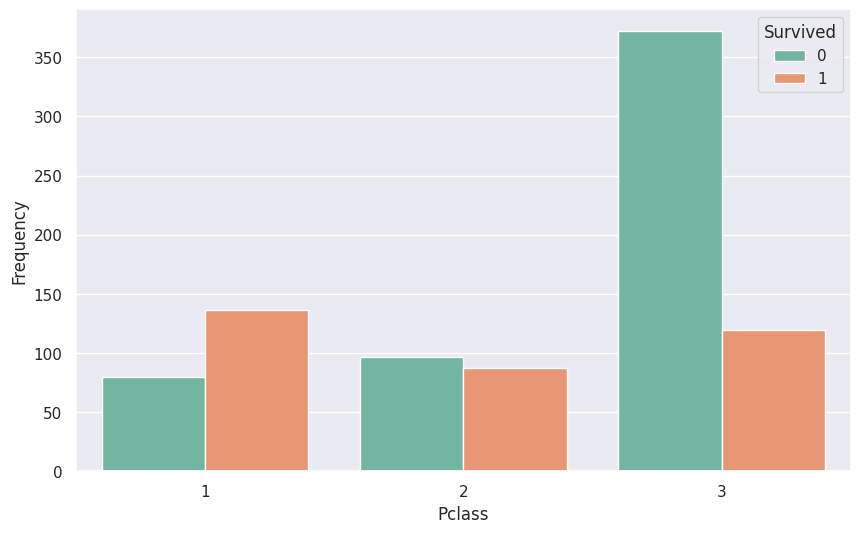

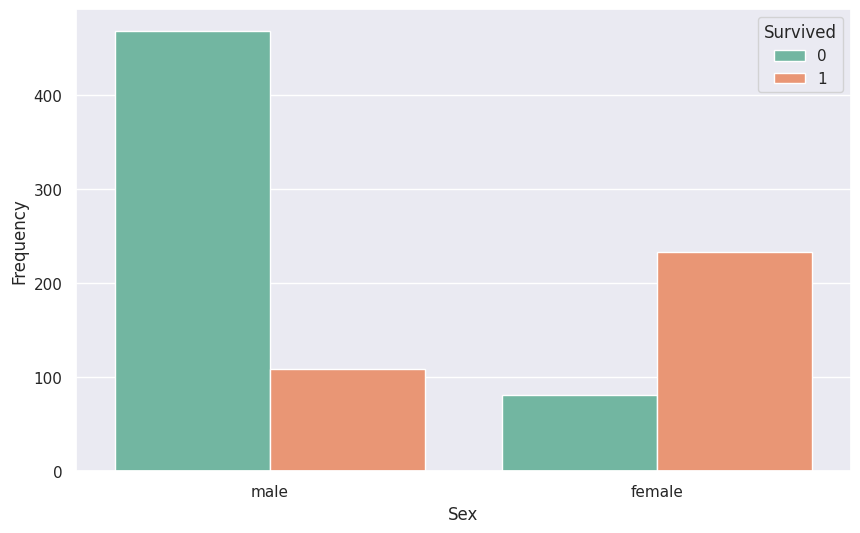

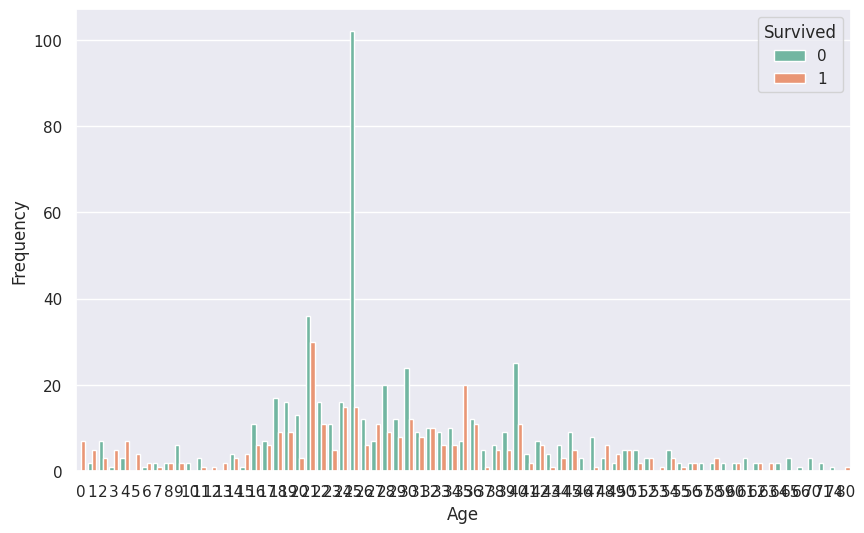

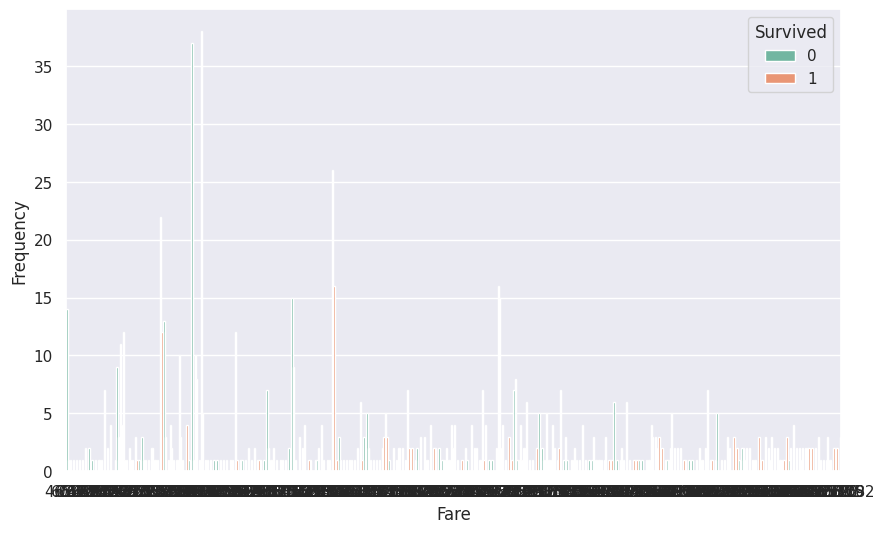

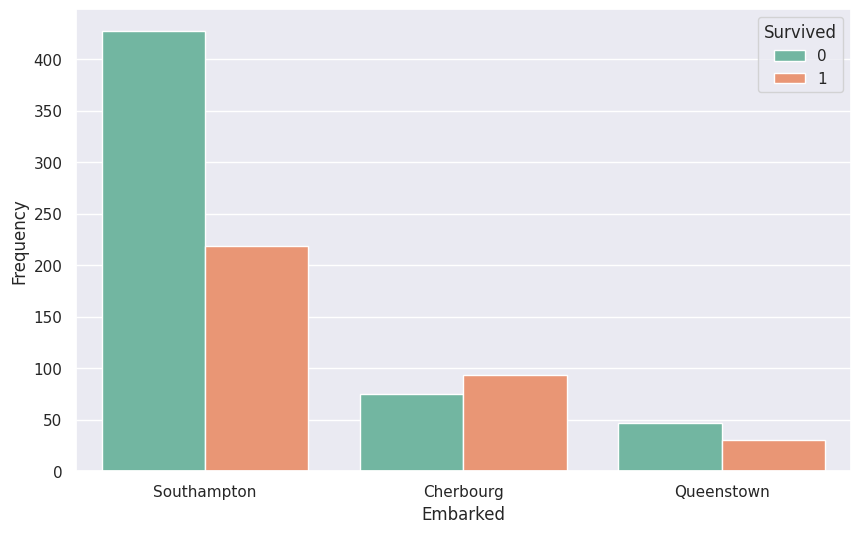

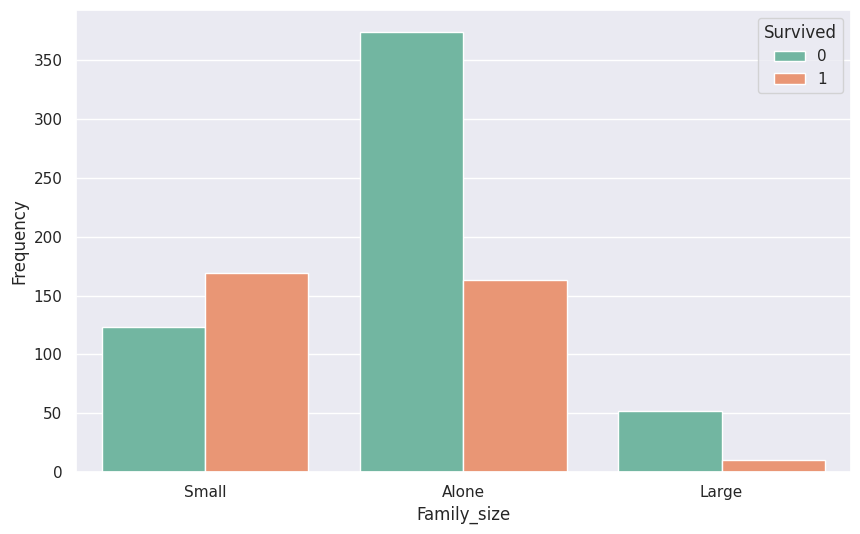

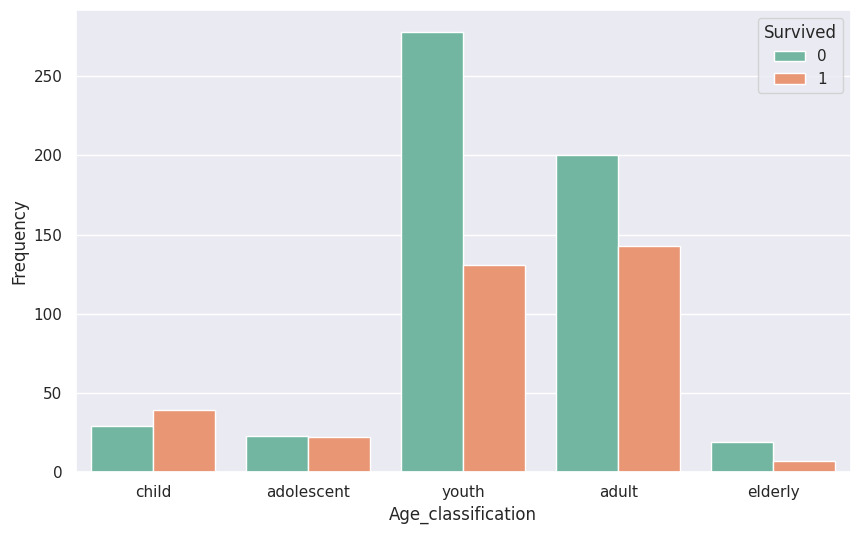

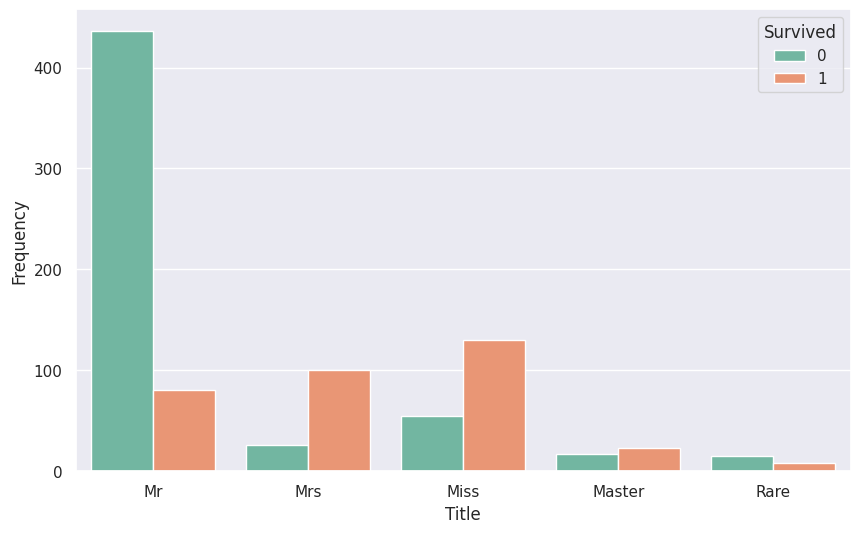

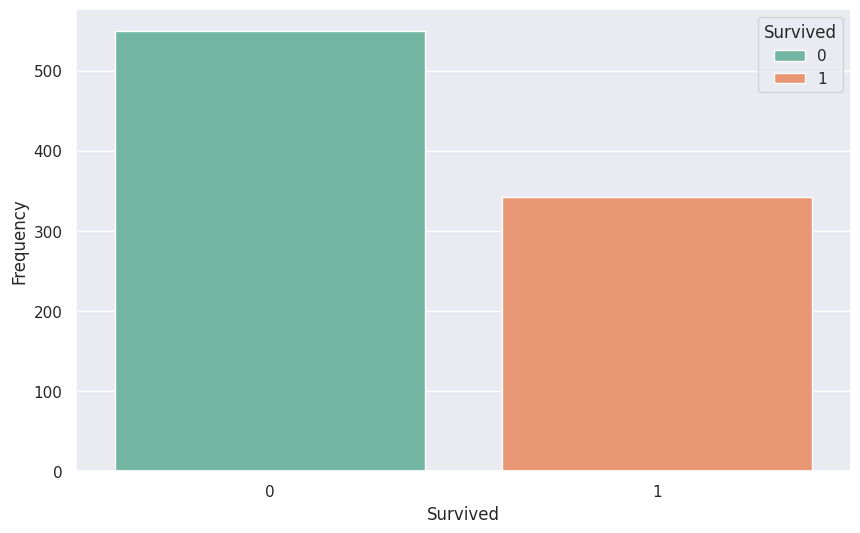

In [374]:
for column in all_columns:
    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, data=X, hue="Survived", palette="Set2")
    plt.ylabel("Frequency")
    plt.savefig(f"results/individual_histograms/{column}.png")
    plt.show()

Convert categorical data into numerical data

In [375]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()

X["Sex"] = enc.fit_transform(X["Sex"].to_frame())
print(list(enc.categories_))
X["Sex"]

[array(['female', 'male'], dtype=object)]


0      1.0
1      0.0
2      0.0
3      0.0
4      1.0
      ... 
886    1.0
887    0.0
888    0.0
889    1.0
890    1.0
Name: Sex, Length: 891, dtype: float64

In [376]:
X["Embarked"] = enc.fit_transform(X["Embarked"].to_frame())
print(list(enc.categories_))
X["Embarked"]

[array(['Cherbourg', 'Queenstown', 'Southampton'], dtype=object)]


0      2.0
1      0.0
2      2.0
3      2.0
4      2.0
      ... 
886    2.0
887    2.0
888    2.0
889    0.0
890    1.0
Name: Embarked, Length: 891, dtype: float64

In [377]:
X["Age_classification"] = enc.fit_transform(X["Age_classification"].to_frame())
print(list(enc.categories_))
X["Age_classification"]

[array(['adolescent', 'adult', 'child', 'elderly', 'youth'], dtype=object)]


0      4.0
1      1.0
2      4.0
3      1.0
4      1.0
      ... 
886    4.0
887    4.0
888    4.0
889    4.0
890    1.0
Name: Age_classification, Length: 891, dtype: float64

In [378]:
X["Title"] = enc.fit_transform(X["Title"].to_frame())
print(list(enc.categories_))
X["Title"]

[array(['Master', 'Miss', 'Mr', 'Mrs', 'Rare'], dtype=object)]


0      2.0
1      3.0
2      1.0
3      3.0
4      2.0
      ... 
886    4.0
887    1.0
888    1.0
889    2.0
890    2.0
Name: Title, Length: 891, dtype: float64

In [379]:
X["Family_size"] = enc.fit_transform(X["Family_size"].to_frame())
print(list(enc.categories_))
X["Family_size"]

[array(['Alone', 'Large', 'Small'], dtype=object)]


0      2.0
1      2.0
2      0.0
3      2.0
4      0.0
      ... 
886    0.0
887    0.0
888    2.0
889    0.0
890    0.0
Name: Family_size, Length: 891, dtype: float64

In [380]:
X.head()

,Pclass,Sex,Age,Fare,Embarked,Family_size,Age_classification,Title,Survived
0,3,1.0,22,7.2500,2.0,2.0,4.0,2.0,0
1,1,0.0,38,71.2833,0.0,2.0,1.0,3.0,1
2,3,0.0,26,7.9250,2.0,0.0,4.0,1.0,1
3,1,0.0,35,53.1000,2.0,2.0,1.0,3.0,1
4,3,1.0,35,8.0500,2.0,0.0,1.0,2.0,0


In [381]:
print(f"Skew (y): {y.skew()}")
print(f"Skew (X):\n{X.skew()}")

Skew (y): 0.4785234382949897
Skew (X):
Pclass               -0.630548
Sex                  -0.618921
Age                   0.529842
Fare                  4.787317
Embarked             -1.264823
Family_size           0.571571
Age_classification   -0.085130
Title                -0.047633
Survived              0.478523
dtype: float64


In [382]:
from scipy.stats import skew

def calculate_metrics(df):

    means = df.mean()           # μ_d
    stds = df.std(ddof=0)       # σ_d (padrão populacional)
    skews = df.apply(lambda x: skew(x, bias=False))  # γ_d (assimetria de Fisher)

    # combina em um DataFrame para visualização
    metrics_df = pd.DataFrame({
        'Mean (μ)': means,
        'Std (σ)': stds,
        'Skewness (γ)': skews
    })
    return metrics_df

In [383]:
# Incondicional
calculate_metrics(X)

,Mean (μ),Std (σ),Skewness (γ)
Pclass,2.308642,0.835602,-0.630548
Sex,0.647587,0.477722,-0.618921
Age,29.072952,13.318858,0.529842
Fare,32.204208,49.665534,4.787317
Embarked,1.536476,0.791059,-1.264823
Family_size,0.725028,0.924557,0.571571
Age_classification,2.461279,1.496503,-0.085130
Title,1.895623,0.788023,-0.047633
Survived,0.383838,0.486319,0.478523


### Quest 1 - Regression Logistic and Linear Discriminant Analysis

1.1 How many predictors would you use to fit the model?

1.2 After training the model, compute the confusion matrix and overall fraction of correct predictions.

1.3 Explain what the confusion matrix is telling you about the types of misclassifications made by the method.

In [384]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# Train test split
X = X.drop(["Survived"], axis=1)

# Converting to numpy arrays
X_numpy, y_numpy = X.to_numpy(), y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_numpy, y_numpy, test_size=0.3
    )

In [385]:
def _as_2d_array(X: np.ndarray) -> np.ndarray:
    """Ensure X is a 2D float64 array."""
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D. Got shape={X.shape}.")
    X = X.astype(np.float64, copy=False)
    if not np.isfinite(X).all():
        raise ValueError("X contains NaN or Inf. Clean/Impute before training.")
    return X

def _as_1d_int(y: np.ndarray) -> np.ndarray:
    """Ensure y is a 1D int array."""
    y = np.asarray(y)
    if y.ndim != 1:
        raise ValueError(f"y must be 1D. Got shape={y.shape}.")
    if not np.isfinite(y).all():
        raise ValueError("y contains NaN or Inf. Clean/Impute before training.")
    return y

def _binary_logloss(y: np.ndarray, p: np.ndarray, eps: float = 1e-12) -> float:
    """Binary cross-entropy."""
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

def _add_intercept(X: np.ndarray) -> np.ndarray:
    """Add a bias column of ones to X."""
    return np.hstack([np.ones((X.shape[0], 1), dtype=X.dtype), X])


def _sigmoid(z: np.ndarray) -> np.ndarray:
    """Numerically stable sigmoid."""
    z = np.asarray(z, dtype=np.float64)
    out = np.empty_like(z)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

In [386]:
class LogisticRegression:
    """
    Logistic regression model.
    - Binary: uses IRLS (Newton) with damping.

    Notes:
    - Standardize features for better conditioning (especially for Newton/IRLS).
    """

    def __init__(
        self,
        fit_intercept: bool = True,
        l2: float = 0.0,
        max_iter: int = 200,
        tol: float = 1e-6,
        lr: float = 0.1,
        solver: str = "auto",  # "auto" | "irls" | "gd"
        random_state: int | None = 42,
    ):
        self.fit_intercept = fit_intercept
        self.l2 = float(l2)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.lr = float(lr)
        self.solver = solver
        self.random_state = random_state

        self.coef_ = None          # shape (n_features,) for binary or (K, n_features) for multiclass
        self.intercept_ = None     # float for binary or (K,) for multiclass
        self.classes_ = None       # unique class labels

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = _as_2d_array(X)
        y = _as_1d_int(y)

        classes = np.unique(y)
        self.classes_ = classes

        if classes.size < 2:
            raise ValueError("y must have at least 2 classes.")
        if classes.size == 2:
            return self._fit_binary(X, y)
        return self._fit_multiclass(X, y)

    def _fit_binary(self, X: np.ndarray, y: np.ndarray):
        # Map to {0,1} in case labels are not 0/1
        cls0, cls1 = self.classes_[0], self.classes_[1]
        y01 = (y == cls1).astype(np.float64)

        Xb = _add_intercept(X) if self.fit_intercept else X
        n, d = Xb.shape

        # Choose solver
        solver = self.solver
        if solver == "auto":
            solver = "irls"  # Newton is usually fast for binary

        w = np.zeros(d, dtype=np.float64)

        if solver == "irls":
            # IRLS / Newton-Raphson with damping for stability
            lam = self.l2
            eye = np.eye(d, dtype=np.float64)

            # Do not regularize intercept (common practice)
            reg_mask = np.ones(d, dtype=np.float64)
            if self.fit_intercept:
                reg_mask[0] = 0.0
            Reg = lam * np.diag(reg_mask)

            prev_loss = np.inf
            for _ in range(self.max_iter):
                z = Xb @ w
                p = _sigmoid(z)

                # Gradient: X^T (p - y) + lambda * w (excluding intercept)
                g = (Xb.T @ (p - y01)) / n + Reg @ w

                # Hessian: X^T R X + lambda I (excluding intercept)
                r = p * (1 - p)
                # Avoid near-zero r causing singular Hessian
                r = np.clip(r, 1e-12, None)
                XR = Xb * r.reshape(-1, 1)
                H = (Xb.T @ XR) / n + Reg

                # Solve H * step = g
                try:
                    step = np.linalg.solve(H, g)
                except np.linalg.LinAlgError:
                    # Fallback: add a small jitter (Levenberg-Marquardt style)
                    jitter = 1e-6
                    step = np.linalg.solve(H + jitter * eye, g)

                # Damping / line search (simple)
                alpha = 1.0
                for _ls in range(20):
                    w_new = w - alpha * step
                    p_new = _sigmoid(Xb @ w_new)
                    loss = _binary_logloss(y01, p_new)
                    # Add L2 penalty (excluding intercept)
                    if self.l2 > 0:
                        if self.fit_intercept:
                            loss += 0.5 * self.l2 * float(np.dot(w_new[1:], w_new[1:]))
                        else:
                            loss += 0.5 * self.l2 * float(np.dot(w_new, w_new))
                    if loss <= prev_loss - 1e-12:
                        w = w_new
                        prev_loss = loss
                        break
                    alpha *= 0.5

                # Convergence by parameter change
                if np.linalg.norm(alpha * step) < self.tol:
                    break

        elif solver == "gd":
            # Gradient descent
            lam = self.l2
            reg_mask = np.ones(d, dtype=np.float64)
            if self.fit_intercept:
                reg_mask[0] = 0.0

            prev_loss = np.inf
            for _ in range(self.max_iter):
                p = _sigmoid(Xb @ w)
                g = (Xb.T @ (p - y01)) / n
                if lam > 0:
                    g += lam * (reg_mask * w)

                w_new = w - self.lr * g
                p_new = _sigmoid(Xb @ w_new)
                loss = _binary_logloss(y01, p_new)
                if lam > 0:
                    loss += 0.5 * lam * float(np.dot((reg_mask * w_new), w_new))
                if abs(prev_loss - loss) < self.tol:
                    w = w_new
                    break
                w = w_new
                prev_loss = loss
        else:
            raise ValueError("solver must be 'auto', 'irls' or 'gd'.")

        # Unpack intercept and coef
        if self.fit_intercept:
            self.intercept_ = float(w[0])
            self.coef_ = w[1:].copy()
        else:
            self.intercept_ = 0.0
            self.coef_ = w.copy()

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.classes_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")
        X = _as_2d_array(X)

        if self.classes_.size == 2:
            if self.fit_intercept:
                z = self.intercept_ + X @ self.coef_
            else:
                z = X @ self.coef_
            p1 = _sigmoid(z)
            p0 = 1.0 - p1
            return np.vstack([p0, p1]).T

    def predict(self, X: np.ndarray) -> np.ndarray:
        P = self.predict_proba(X)
        idx = np.argmax(P, axis=1)
        return self.classes_[idx]


In [387]:
class LDA:
    """
    Linear Discriminant Analysis.
    - Estimates class means, pooled covariance, and priors.
    - Predicts via linear discriminant scores.

    Notes:
    - Works best when features are roughly Gaussian-like per class.
    - Use shrinkage to improve stability when covariance is ill-conditioned.
    """

    def __init__(self, priors: np.ndarray | None = None, shrinkage: float = 0.0):
        self.priors = priors
        self.shrinkage = float(shrinkage)

        self.classes_ = None
        self.means_ = None          # (K, d)
        self.priors_ = None         # (K,)
        self.cov_ = None            # (d, d)
        self.precision_ = None      # (d, d) inverse covariance

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = _as_2d_array(X)
        y = _as_1d_int(y)

        classes = np.unique(y)
        if classes.size < 2:
            raise ValueError("y must have at least 2 classes.")
        self.classes_ = classes

        n, d = X.shape
        K = classes.size

        # Compute means per class and priors
        means = np.zeros((K, d), dtype=np.float64)
        counts = np.zeros(K, dtype=np.int64)

        for i, c in enumerate(classes):
            Xi = X[y == c]
            if Xi.size == 0:
                raise ValueError(f"Empty class encountered: {c}.")
            means[i] = Xi.mean(axis=0)
            counts[i] = Xi.shape[0]

        if self.priors is None:
            priors = counts / counts.sum()
        else:
            priors = np.asarray(self.priors, dtype=np.float64)
            if priors.shape != (K,):
                raise ValueError(f"priors must have shape ({K},). Got {priors.shape}.")
            if np.any(priors < 0) or not np.isfinite(priors).all():
                raise ValueError("priors must be non-negative and finite.")
            s = priors.sum()
            if s <= 0:
                raise ValueError("priors must sum to a positive value.")
            priors = priors / s

        # Pooled covariance (maximum likelihood estimate with shared covariance)
        cov = np.zeros((d, d), dtype=np.float64)
        for i, c in enumerate(classes):
            Xi = X[y == c] - means[i]
            cov += Xi.T @ Xi

        # Use (n - K) denominator for unbiased pooled estimate; ML often uses n.
        denom = max(n - K, 1)
        cov /= denom

        # Invert covariance robustly
        try:
            precision = np.linalg.inv(cov)
        except np.linalg.LinAlgError:
            # Fallback to pseudo-inverse if singular
            precision = np.linalg.pinv(cov)

        self.means_ = means
        self.priors_ = priors
        self.cov_ = cov
        self.precision_ = precision
        return self

    def _scores(self, X: np.ndarray) -> np.ndarray:
        X = _as_2d_array(X)
        if self.classes_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")

        means = self.means_
        P = self.precision_
        log_priors = np.log(np.clip(self.priors_, 1e-300, None))

        # Compute delta_k(x) for each class k
        # delta_k = x^T P mu_k - 0.5 * mu_k^T P mu_k + log(pi_k)
        Xm = X @ P  # (n, d)
        term1 = Xm @ means.T  # (n, K)

        quad = np.einsum("kd,dd,kd->k", means, P, means)  # (K,)
        term2 = 0.5 * quad.reshape(1, -1)

        return term1 - term2 + log_priors.reshape(1, -1)

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = self._scores(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]

In [388]:
logreg = LogisticRegression(fit_intercept=True, l2=1e-3, solver="irls")
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

In [389]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.76      0.87      0.82       159
           1       0.77      0.61      0.68       109

    accuracy                           0.76       268
   macro avg       0.77      0.74      0.75       268
weighted avg       0.77      0.76      0.76       268



In [390]:
lda = LDA(shrinkage=0.05)
lda.fit(X_train, y_train)
pred_lda = lda.predict(X_test)

In [391]:
print(classification_report(y_test, pred_lda))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82       159
           1       0.75      0.66      0.70       109

    accuracy                           0.77       268
   macro avg       0.77      0.75      0.76       268
weighted avg       0.77      0.77      0.77       268



In [398]:
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SkLDA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Comparing the custom models with sklearn's native implementations
def compare_models(X_train, y_train, X_test, y_test):
    
    lambda_reg = 0.001 
    C_sklearn = 1 / lambda_reg  

    models = [
        {
            "Name": "Custom Logistic Regression",
            "Model": LogisticRegression(l2=lambda_reg, solver='irls', max_iter=100),
            "Type": "Custom"
        },
        {
            "Name": "Sklearn Logistic Regression",
            "Model": SkLR(penalty='l2', C=C_sklearn, solver='lbfgs', max_iter=1000),
            "Type": "Native"
        },
        {
            "Name": "Custom LDA",
            "Model": LDA(),  
            "Type": "Custom"
        },
        {
            "Name": "Sklearn LDA",
            "Model": SkLDA(solver='lsqr'), 
            "Type": "Native"
        }
    ]
    
    results = []
    
    print(f"{'Model':<30} | {'Acurácia':<10}")
    print("-" * 45)
    
    for m in models:
        model_name = m["Name"]
        model_inst = m["Model"]

        try:
            model_inst.fit(X_train, y_train)
            
            y_pred = model_inst.predict(X_test)
            
        except Exception as e:
            print(f"Erro no modelo {model_name}: {e}")
            continue
            
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='binary') 
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        
        print(f"{model_name:<30} | {acc:.4f}")
        
        results.append({
            "Method": model_name,
            "Type": m["Type"],
            "Accuracy": acc,
            "F1-Score": f1,
            "Precision": prec,
            "Recall": rec,
        })
        
    return pd.DataFrame(results)

comparison_df = compare_models(X_train, y_train, X_test, y_test)

print("\n=== Comparative Table ===")
display(comparison_df.sort_values(by="Accuracy", ascending=False))  
   

Model                          | Acurácia  
---------------------------------------------
Custom Logistic Regression     | 0.7649
Sklearn Logistic Regression    | 0.7612
Custom LDA                     | 0.7724
Sklearn LDA                    | 0.7649

=== Comparative Table ===


,Method,Type,Accuracy,F1-Score,Precision,Recall
2,Custom LDA,Custom,0.772388,0.702439,0.750000,0.660550
0,Custom Logistic Regression,Custom,0.764925,0.676923,0.767442,0.605505
3,Sklearn LDA,Native,0.764925,0.686567,0.750000,0.633028
1,Sklearn Logistic Regression,Native,0.761194,0.673469,0.758621,0.605505


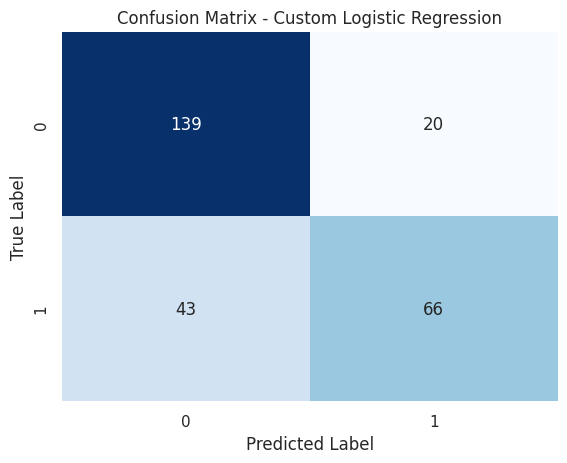

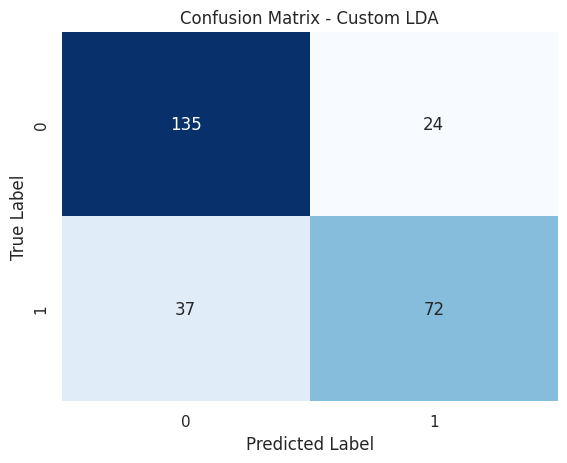

In [399]:
# Now, after we have compared the models and they performed similarly, we can proceed with the confusion matrix analysis.

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f"results/confusion_matrix_{model_name.replace(' ', '_').lower()}.png")
    plt.show()

# Plot confusion matrices for both models
plot_confusion_matrix(y_test, pred, "Custom Logistic Regression")
plot_confusion_matrix(y_test, pred_lda, "Custom LDA")

### Quest 2 - Quadratic Discriminant Analysis, Neural Networks, K-Nearest Neighbours and Support Vector Machines

2.1 Depending on your selection of method, tune the model in a convenient way (if needed use cross-validation).

2.2 After training the model, compute the confusion matrix and overall fraction of correct predictions.

2.3 Explain the confusion matrix and the types of misclassifications made by the method.

In [ ]:
class QDA:
    """
    Quadratic Discriminant Analysis.
    - Class-specific covariance matrices.
    - Uses log-det and quadratic form.
    - Regularization via shrinkage to diagonal.
    """

    def __init__(self, priors=None, shrinkage=0.0, eps=1e-12):
        self.priors = priors
        self.shrinkage = float(shrinkage)
        self.eps = float(eps)

        self.classes_ = None
        self.means_ = None        # (K, d)
        self.priors_ = None       # (K,)
        self.covs_ = None         # (K, d, d)
        self.precs_ = None        # (K, d, d)
        self.logdets_ = None      # (K,)

    def fit(self, X, y):
        X = _as_2d_array(X)
        y = _as_1d_int(y)

        classes = np.unique(y)
        if classes.size < 2:
            raise ValueError("y must have at least 2 classes.")
        self.classes_ = classes

        n, d = X.shape
        K = classes.size

        means = np.zeros((K, d), dtype=np.float64)
        covs = np.zeros((K, d, d), dtype=np.float64)
        precs = np.zeros((K, d, d), dtype=np.float64)
        logdets = np.zeros(K, dtype=np.float64)
        counts = np.zeros(K, dtype=np.int64)

        for i, c in enumerate(classes):
            Xi = X[y == c]
            counts[i] = Xi.shape[0]
            if counts[i] < 2:
                raise ValueError(f"Class {c} has <2 samples; covariance is unreliable.")
            means[i] = Xi.mean(axis=0)

            Xc = Xi - means[i]
            cov = (Xc.T @ Xc) / max(counts[i] - 1, 1)

            a = self.shrinkage
            if not (0.0 <= a <= 1.0):
                raise ValueError("shrinkage must be in [0, 1].")
            if a > 0:
                cov = (1 - a) * cov + a * np.diag(np.diag(cov))

            # Stabilize tiny variances
            cov = cov + self.eps * np.eye(d)

            covs[i] = cov
            try:
                precs[i] = np.linalg.inv(cov)
            except np.linalg.LinAlgError:
                precs[i] = np.linalg.pinv(cov)

            sign, ld = np.linalg.slogdet(cov)
            # If sign <= 0, covariance is numerically bad; slogdet still gives something but warn-worthy.
            logdets[i] = ld

        if self.priors is None:
            priors = counts / counts.sum()
        else:
            priors = np.asarray(self.priors, dtype=np.float64)
            if priors.shape != (K,):
                raise ValueError(f"priors must have shape ({K},). Got {priors.shape}.")
            priors = priors / priors.sum()

        self.means_ = means
        self.covs_ = covs
        self.precs_ = precs
        self.logdets_ = logdets
        self.priors_ = priors
        return self

    def _scores(self, X):
        X = _as_2d_array(X)
        if self.classes_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")

        n, d = X.shape
        K = self.classes_.size
        scores = np.zeros((n, K), dtype=np.float64)

        log_priors = np.log(np.clip(self.priors_, 1e-300, None))

        for k in range(K):
            mu = self.means_[k]
            P = self.precs_[k]
            xc = X - mu  # (n, d)
            # quadratic form per sample: (x-mu)^T P (x-mu)
            q = np.einsum("nd,dd,nd->n", xc, P, xc)
            scores[:, k] = -0.5 * (self.logdets_[k] + q) + log_priors[k]

        return scores

    def predict(self, X):
        scores = self._scores(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        scores = self._scores(X)
        return _softmax(scores)

In [ ]:
class MLP:
    def __init__(self, input_shape:int, hidden_shape:list, output_shape:int) -> None:
        self.input_shape = input_shape
        self.hidden_shape = hidden_shape
        self.output_shape = output_shape
        self.num_layers = len(hidden_shape) + 1

        self.rng = np.random.default_rng(2000)

        # Initialize the weights and biases for each layer using Xavier initialization
        self.weights: List[np.ndarray] = []
        self.biases: List[np.ndarray] = []

        sizes = [input_shape] + hidden_shape + [output_shape]
        for i in range(1, self.num_layers + 1):
            fan_in, fan_out = sizes[i - 1], sizes[i]
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            w = self.rng.uniform(-limit, limit, size=(fan_out, fan_in)).astype(np.float32)
            b = np.zeros((fan_out, 1), dtype=np.float32)
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        # Ensure numpy array with correct dtype
        X = np.asarray(X, dtype=np.float32)
        # Basic shape check
        if X.shape[0] != self.input_shape:
            raise ValueError(f"Expected X with shape ({self.input_shape}, m), got {X.shape}")

        # Forward pass through the network
        self.activations: List[np.ndarray] = [X]
        self.z = []

        for i in range(self.num_layers):
            #print("DEBUG - Forward section: started")
            #print(f"Shape of weights: {self.weights[i].shape}")
            #print(f"Shape of activations: {self.activations[i].shape}")
            #print(f"Shape of biases: {self.biases[i].shape}")
            #print("DEBUG - Forward section: finished")

            # Dot product
            z = np.dot(self.weights[i], self.activations[i]) + self.biases[i]
            self.z.append(z)
            if i < self.num_layers - 1:
                a = self.tanh(z)  # Tanh activation for hidden layers
            else:
                a = self.sigmoid(z)  # Sigmoid for binary classification
            self.activations.append(a)
        return self.activations[-1]  # shape: (output_size, m)

    def backward(self, y):
        # Ensure numpy array
        y = np.asarray(y, dtype=np.float32)

        # Make sure y has shape (output_dim, m)
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # Number of training examples based on stored input
        m = self.activations[0].shape[1]

        # Compute gradients
        gradients = []
        dZ = self.activations[-1] - y  # shape: (output_size, m)
        dZ = np.clip(dZ, -5, 5)
        for i in range(self.num_layers - 1, -1, -1):
            dW = (1 / m) * np.dot(dZ, self.activations[i].T)  # shape: (sizes[i], sizes[i-1])
            db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)  # shape: (sizes[i], 1)
            gradients.append((dW, db))

            if i > 0:
                dA = np.dot(self.weights[i].T, dZ)  # shape: (sizes[i-1], m)
                #a_prev = self.activations[i]
                dZ = dA * self.gradient_tanh(self.z[i-1])  # shape: (sizes[i-1], m)

        return gradients[::-1]  # Reverse the gradients

    def compute_loss(self, y_true, y_pred):
        """Calcula a loss apropriada baseada no tipo de problema"""
        y_true = np.asarray(y_true, dtype=np.float32)
        if y_true.ndim == 1:
            y_true = y_true.reshape(-1, 1)

        m = y_true.shape[1]

        if self.output_shape == 1:
            # Binary Cross-Entropy
            epsilon = 1e-15  # Para evitar log(0)
            y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
            loss = -(1 / m) * np.sum(
                y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
            )
        return loss

    def _validate_X(self, X):
      if isinstance(X, pd.DataFrame):
          X_arr = X.to_numpy()
      else:
          X_arr = np.asarray(X, dtype=np.float32)

      if X_arr.ndim != 2:
          raise ValueError("X must be a 2D array.")

      # Case: X is (m, d)
      if X_arr.shape[1] == self.input_shape and X_arr.shape[0] != self.input_shape:
          return X_arr.T  # (d, m)

      # Case: X already (d, m)
      if X_arr.shape[0] == self.input_shape:
          return X_arr

      raise ValueError(
          f"Cannot infer X layout. Got {X_arr.shape}, expected input_shape={self.input_shape}."
      )

    def _validate_y(self, y, X):
      Xp = self._validate_X(X)
      m = Xp.shape[1]

      if isinstance(y, (pd.DataFrame, pd.Series)):
          yp = y.to_numpy()
      else:
          yp = np.asarray(y, dtype=np.float32)

      if yp.ndim == 1:
          if yp.shape[0] != m:
              raise ValueError(f"y length must match samples m={m}. Got {yp.shape[0]}.")
          if self.output_shape != 1:
              raise ValueError("For multiclass, y must be one-hot (m, C) or (C, m).")
          return yp.reshape(1, -1)

      if yp.ndim == 2:
          # (m, C) -> (C, m)
          if yp.shape[0] == m:
              yp = yp.T
          elif yp.shape[1] == m:
              pass
          else:
              raise ValueError(f"y must match samples m={m}. Got {yp.shape}.")

          if yp.shape[0] != self.output_shape:
              raise ValueError(f"y has C={yp.shape[0]} outputs but model expects output_shape={self.output_shape}.")
          return yp

      raise ValueError(f"Unsupported y.ndim={yp.ndim}.")

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 500,
        batch_size: int | None = None,
        verbose: int = 1,
        shuffle: bool = True,
        learning_rate: float = 0.01
    ) -> dict:
      Xp = self._validate_X(X)        # (d, m)
      yp = self._validate_y(y, X)     # (C, m)
      d, m = Xp.shape
      C, my = yp.shape

      N = Xp.shape[1]
      bs = batch_size or N
      history = {"loss": []} # Added 'w' initialization
      idx = np.arange(m)

      # Now X_processed is (n_features, m) and y_processed is (output_dim, m)
      for i, epoch in enumerate(range(epochs)):
        if shuffle and bs < N:
          np.random.shuffle(idx)

        batch_losses = []
        for start in range(0, m, bs):
          end = min(start + bs, N)
          batch_idx = idx[start:end]
          Xb = Xp[:, batch_idx]
          yb = yp[:, batch_idx]

          outputs = self.forward(Xb)
          # Loss function based on task (bin_class: binary-cross entropy)
          loss = self.compute_loss(yb, outputs)
          batch_losses.append(float(loss))

          gradients = self.backward(yb)
          self.update_parameters(gradients, learning_rate)

        history["loss"].append(float(np.mean(batch_losses)))

        if (i + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.6f}")

      return history

    def update_parameters(self, gradients, learning_rate):
        # Update parameters using gradients and learning rate
        for i in range(self.num_layers):
            self.weights[i] -= learning_rate * gradients[i][0]
            self.biases[i] -= learning_rate * gradients[i][1]

    def sigmoid(self, Z):
        # Sigmoid activation for binary classification
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def gradient_sigmoid(self, Z):
        # Gradient of sigmoid
        s = self.sigmoid(Z)
        return s * (1 - s)

    def softmax(self, Z):
        # Softmax activation for multiclass classification
        # Subtract max for numerical stability
        exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

    def tanh(self, Z):
        # Hyperbolic tangent (tanh) activation function
        return np.tanh(Z)

    def gradient_tanh(self, Z):
        # Gradient of the hyperbolic tangent (tanh) activation function
        a = self.tanh(Z)
        return 1 - a**2

In [ ]:
class KNN:
    """
    KNN classifier.
    - Supports Euclidean distance
    - Supports uniform or distance-weighted voting
    """

    def __init__(self, k=5, weights="uniform", eps=1e-12):
        if k < 1:
            raise ValueError("k must be >= 1.")
        if weights not in ("uniform", "distance"):
            raise ValueError("weights must be 'uniform' or 'distance'.")
        self.k = int(k)
        self.weights = weights
        self.eps = float(eps)

        self.X_ = None
        self.y_ = None
        self.classes_ = None

    def fit(self, X, y):
        X = _as_2d_array(X)
        y = _as_1d_int(y)

        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same number of samples.")

        self.X_ = X
        self.y_ = y
        self.classes_ = np.unique(y)
        return self

    def _pairwise_distances(self, X):
        """Compute squared Euclidean distances between X and self.X_."""
        # (n_test, 1, d) - (1, n_train, d) -> (n_test, n_train, d)
        diff = X[:, None, :] - self.X_[None, :, :]
        return np.sum(diff * diff, axis=2)  # squared distances

    def predict(self, X):
        if self.X_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")
        X = _as_2d_array(X)

        d2 = self._pairwise_distances(X)  # (n_test, n_train)
        # indices of k smallest distances
        idx = np.argpartition(d2, kth=min(self.k, d2.shape[1]-1), axis=1)[:, : self.k]

        preds = []
        for i in range(X.shape[0]):
            neigh_idx = idx[i]
            neigh_y = self.y_[neigh_idx]
            neigh_d = np.sqrt(d2[i, neigh_idx])

            if self.weights == "uniform":
                # majority vote
                values, counts = np.unique(neigh_y, return_counts=True)
                preds.append(values[np.argmax(counts)])
            else:
                # distance-weighted vote: weight = 1/(dist + eps)
                w = 1.0 / (neigh_d + self.eps)
                # accumulate weights per class
                score = {}
                for label, weight in zip(neigh_y, w):
                    score[label] = score.get(label, 0.0) + float(weight)
                preds.append(max(score.items(), key=lambda t: t[1])[0])

        return np.array(preds)

    def predict_proba(self, X):
        """Class probability estimates (simple vote proportions / weighted proportions)."""
        if self.X_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")
        X = _as_2d_array(X)

        d2 = self._pairwise_distances(X)
        idx = np.argpartition(d2, kth=min(self.k, d2.shape[1]-1), axis=1)[:, : self.k]

        proba = np.zeros((X.shape[0], self.classes_.size), dtype=np.float64)
        class_to_col = {c: j for j, c in enumerate(self.classes_)}

        for i in range(X.shape[0]):
            neigh_idx = idx[i]
            neigh_y = self.y_[neigh_idx]
            neigh_d = np.sqrt(d2[i, neigh_idx])

            if self.weights == "uniform":
                for label in neigh_y:
                    proba[i, class_to_col[label]] += 1.0
                proba[i] /= proba[i].sum()
            else:
                w = 1.0 / (neigh_d + self.eps)
                for label, weight in zip(neigh_y, w):
                    proba[i, class_to_col[label]] += float(weight)
                proba[i] /= proba[i].sum()

        return proba

In [ ]:
class SVM:
    """
    A linear SVM using SGD on hinge loss (soft-margin).
    - Binary classification: y in {0,1} or {neg,pos} labels
    """

    def __init__(self, C=1.0, lr=0.01, max_iter=2000, fit_intercept=True, batch_size=64, random_state=42):
        if C <= 0:
            raise ValueError("C must be > 0.")
        if lr <= 0:
            raise ValueError("lr must be > 0.")
        if max_iter < 1:
            raise ValueError("max_iter must be >= 1.")
        if batch_size < 1:
            raise ValueError("batch_size must be >= 1.")

        self.C = float(C)
        self.lr = float(lr)
        self.max_iter = int(max_iter)
        self.fit_intercept = bool(fit_intercept)
        self.batch_size = int(batch_size)
        self.random_state = int(random_state)

        self.classes_ = None
        self.W_ = None  # (K, d) for multiclass; (d,) for binary
        self.b_ = None  # (K,) for multiclass; float for binary

    def _add_bias(self, X):
        if not self.fit_intercept:
            return X
        return np.hstack([np.ones((X.shape[0], 1), dtype=X.dtype), X])

    def fit(self, X, y):
        X = _as_2d_array(X)
        y = _as_1d_int(y)

        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same number of samples.")

        classes = np.unique(y)
        if classes.size < 2:
            raise ValueError("y must have at least 2 classes.")
        self.classes_ = classes

        Xb = self._add_bias(X)
        n, d = Xb.shape

        rng = np.random.default_rng(self.random_state)

        if classes.size == 2:
            # Binary: map to {-1, +1}
            c0, c1 = classes[0], classes[1]
            ypm = np.where(y == c1, 1.0, -1.0)

            w = rng.normal(0, 0.01, size=d).astype(np.float64)

            # Hinge loss with L2 regularization: 0.5||w||^2 + C * mean(max(0,1 - y*(Xw)))
            # SGD updates:
            for t in range(1, self.max_iter + 1):
                idx = rng.integers(0, n, size=min(self.batch_size, n))
                Xs = Xb[idx]
                ys = ypm[idx]

                margins = ys * (Xs @ w)
                mask = margins < 1.0  # hinge active

                # Gradient: w - C * mean( y_i * x_i ) over active samples (bias included in w)
                grad = w.copy()
                if np.any(mask):
                    grad -= self.C * (Xs[mask].T @ ys[mask]) / max(mask.sum(), 1)

                w -= self.lr * grad

            # Unpack
            if self.fit_intercept:
                self.b_ = float(w[0])
                self.W_ = w[1:].copy()
            else:
                self.b_ = 0.0
                self.W_ = w.copy()

            return self

    def decision_function(self, X):
        if self.classes_ is None:
            raise RuntimeError("Model not fitted. Call fit() first.")
        X = _as_2d_array(X)

        if self.classes_.size == 2:
            return (X @ self.W_) + self.b_

        # Multiclass OVR scores: higher => more likely
        return (X @ self.W_.T) + self.b_.reshape(1, -1)

    def predict(self, X):
        scores = self.decision_function(X)

        if self.classes_.size == 2:
            # threshold at 0
            return np.where(scores >= 0, self.classes_[1], self.classes_[0])

        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]

    def predict_proba(self, X):
        """
        SVM doesn't naturally output probabilities.
        Here we provide a heuristic: softmax over OVR scores (multiclass) or sigmoid (binary).
        For calibrated probabilities, use Platt scaling / isotonic on a validation set.
        """
        scores = self.decision_function(X)

        if self.classes_.size == 2:
            # heuristic sigmoid on margin
            p1 = 1.0 / (1.0 + np.exp(-scores))
            p0 = 1.0 - p1
            return np.vstack([p0, p1]).T

        return _softmax(scores)

In [ ]:
qda = QDA(shrinkage=0.05)
qda.fit(X_train, y_train)
pred_qda = qda.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_lda))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       171
           1       0.73      0.71      0.72        97

    accuracy                           0.80       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.80      0.80      0.80       268



In [ ]:
# Expand dimensions for mlp_classifier
y_train_exp = np.asarray(y_train, dtype=np.float32).reshape(1, -1)

input_shape = X_train.shape[1]
output_shape = y_train_exp.shape[0]
hidden_shape = [30, 30]

num_epochs = 1000
learning_rate = 0.1

print(f"input_shape: {input_shape}")
print(f"output_shape: {output_shape}")

input_shape: 8
output_shape: 1


In [ ]:
mlp_classifier = MLP(
    input_shape=input_shape,
    hidden_shape=hidden_shape,
    output_shape=output_shape,
)

In [ ]:
history_mlp = mlp_classifier.fit(
    X=X_train,
    y=y_train_exp,
    epochs=1000,
    batch_size=32,
    learning_rate=0.01)

Epoch 100/1000 | Loss: 0.446881
Epoch 200/1000 | Loss: 0.635345
Epoch 300/1000 | Loss: 0.341763
Epoch 400/1000 | Loss: 0.461924
Epoch 500/1000 | Loss: 0.580157
Epoch 600/1000 | Loss: 0.174359
Epoch 700/1000 | Loss: 0.317530
Epoch 800/1000 | Loss: 0.420985
Epoch 900/1000 | Loss: 0.532089
Epoch 1000/1000 | Loss: 0.479713


In [ ]:
outputs = mlp_classifier.forward(X_test.T)

# Convert one-hot encoded y_derm_te back to original class labels
y_true_labels = y_test
# Convert continuous probability outputs to discrete class labels
y_pred_labels = (outputs[0] >= 0.5).astype(int)

print(f"Shape of y_true_labels: {y_true_labels.shape}")
print(f"Shape of y_pred_labels: {y_pred_labels.shape}")

# Pass the discrete predicted labels to confusion_matrix
cm = confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)
"""
TP FP
TN FN
"""

print("Confusion matrix:")
print(cm)

Shape of y_true_labels: (268,)
Shape of y_pred_labels: (268,)
Confusion matrix:
[[153  18]
 [ 45  52]]


In [ ]:
knn = KNN(k=8)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_knn))

              precision    recall  f1-score   support

           0       0.72      0.84      0.78       171
           1       0.61      0.43      0.51        97

    accuracy                           0.69       268
   macro avg       0.67      0.64      0.64       268
weighted avg       0.68      0.69      0.68       268



In [ ]:
svm = SVM()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

           0       0.80      0.47      0.60       171
           1       0.46      0.79      0.58        97

    accuracy                           0.59       268
   macro avg       0.63      0.63      0.59       268
weighted avg       0.68      0.59      0.59       268



### Quest 3 - Linear Methods vs Non-Linear Methods

3.1 Compare the results obtained using the linear and nonlinear classification methods.

3.2 Does the nonlinear structure improve the classification performance?